# Model Comparison — Directional Weighted MSE

Compares every spread-prediction model in this project using **Directional Weighted MSE (DWMSE)** as the primary metric.

DWMSE penalises predictions that get the *direction* wrong — which matters for a trading strategy, since a confident wrong-direction call is strictly worse than a noisy right-direction one.

$$L(y, \hat{y}) = \tfrac{1}{2}\bigl[\,1 + \gamma \cdot \mathbf{1}\{\operatorname{sign}(y) \neq \operatorname{sign}(\hat{y})\}\bigr]\cdot(y - \hat{y})^2$$

With $\gamma = 1$ (the project default), a correctly-signed prediction contributes $\tfrac{1}{2}(y-\hat{y})^2$ and an incorrectly-signed one contributes $(y-\hat{y})^2$ — a 2× penalty for sign errors.

**Models compared (all using Kalman spread):**
* OU
* ARMA (walk-forward ARIMA(p,0,q))
* Linear Regression
* XGBoost
* LSTM (point-forecast)
* LSTM Encoder-Decoder

All predictions target the 10-day change in the Kalman spread.

## 1. Imports & setup

In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import sys

# Find repo root by looking upward for the folder that contains "src"
cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent

if not (repo_root / "src").exists():
    raise FileNotFoundError("Could not find project root containing 'src/'")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "semibold"

from src.config import DEFAULT_CONFIG
from src.models.prediction_metrics import (
    directional_weighted_mse,
    evaluate_regression_predictions,
    DEFAULT_DIRECTIONAL_MSE_GAMMA,
)

Repo root: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading


## 2. Configuration

Every ML model writes to `data/processed/predictions/<model_folder>/<window>/predictions.csv` with the unified schema `(Date, pair, predicted_change, predicted_value, predicted_z)`. The OU family is the exception — it writes one wide CSV with per-variant prediction columns.

In [2]:
PROCESSED_DIR = DEFAULT_CONFIG.processed_dir
PREDICTIONS_ROOT = PROCESSED_DIR / "predictions"
PAIR_DATASETS_ROOT = PROCESSED_DIR / "pair_datasets"
OU_SIGNALS_PATH = PROCESSED_DIR / "ou_signals_kalman.csv"

GAMMA = DEFAULT_DIRECTIONAL_MSE_GAMMA  # sign-mismatch penalty weight

# (display_name, folder_name_under_predictions/, spread_type)
MODELS = [
    ("ARMA (Kalman)",          "arma_kalman",                 "kalman"),
    ("Linear Reg (Kalman)",    "linear_regression_kalman",    "kalman"),
    ("LSTM (Kalman)",          "lstm_kalman",                 "kalman"),
    ("LSTM Enc-Dec (Kalman)",  "lstm_encoder_decoder_kalman", "kalman"),
    ("XGBoost (Kalman)",       "xgboost_kalman",              "kalman"),
]

LABEL_COL = {"kalman": "label_kalman_10d"}
SPREAD_COL = {"kalman": "spread_kalman"}

print(f"Predictions root   : {PREDICTIONS_ROOT}")
print(f"Pair datasets root : {PAIR_DATASETS_ROOT}")
print(f"DWMSE gamma        : {GAMMA}")

Predictions root   : /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/predictions
Pair datasets root : /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/pair_datasets
DWMSE gamma        : 1.0


## 3. Loaders

- `load_actuals_for_window` pulls the ground-truth 10-day change from the pair dataset for a given (window, spread-type).
- `load_predictions_for_model` reads every window's `predictions.csv` for one model and stacks them, normalising the occasional `predicted_spread_change` column name from the linear-regression output.

In [3]:
def load_actuals_for_window(window: str, spread_type: str) -> pd.DataFrame:
    """Return a frame of (Date, pair, actual_change, current_spread, rolling_vol_20d, split)
    for the val and/or test split of one window."""
    label_col  = LABEL_COL[spread_type]
    spread_col = SPREAD_COL[spread_type]
    frames = []
    for split_name in ("val", "test"):
        path = PAIR_DATASETS_ROOT / window / f"{split_name}_pair_dataset.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path, parse_dates=["Date"])
        missing = {label_col, spread_col} - set(df.columns)
        if missing:
            continue
        keep_cols = ["Date", "pair", label_col, spread_col]
        if "rolling_vol_20d" in df.columns:
            keep_cols.append("rolling_vol_20d")
        keep = df[keep_cols].copy().rename(columns={
            label_col: "actual_change",
            spread_col: "current_spread",
        })
        keep["split"] = split_name
        frames.append(keep)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out["pair"] = out["pair"].astype(str)
    return out.dropna(subset=["actual_change"])


def load_predictions_for_model(folder: str) -> pd.DataFrame:
    """Read every window's predictions.csv for one model folder into a long frame."""
    root = PREDICTIONS_ROOT / folder
    if not root.exists():
        return pd.DataFrame()
    frames = []
    for window_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        # Prefer the unified predictions.csv; fall back to split-specific files
        candidates = [
            window_dir / "predictions.csv",
            window_dir / "predictions_val.csv",
            window_dir / "predictions_test.csv",
        ]
        seen_file = False
        for pred_path in candidates:
            if not pred_path.exists():
                continue
            df = pd.read_csv(pred_path, parse_dates=["Date"])
            if df.empty:
                continue
            # Linear regression writes 'predicted_spread_change'
            if "predicted_spread_change" in df.columns and "predicted_change" not in df.columns:
                df = df.rename(columns={"predicted_spread_change": "predicted_change"})
            if "predicted_change" not in df.columns:
                continue
            df["window"] = window_dir.name
            df["pair"] = df["pair"].astype(str)
            frames.append(df)
            seen_file = True
            # predictions.csv is authoritative; skip the split-specific ones
            if pred_path.name == "predictions.csv":
                break
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

In [4]:
def merge_with_actuals(preds: pd.DataFrame, spread_type: str) -> pd.DataFrame:
    """Join predictions to actual_change on (window, Date, pair). Any row without a
    matching actual is dropped (typically last few dates of a window where the
    10-day horizon spills past the dataset)."""
    if preds.empty:
        return preds
    out = []
    for window, wdf in preds.groupby("window", sort=True):
        actuals = load_actuals_for_window(window, spread_type)
        if actuals.empty:
            continue
        joined = wdf.merge(
            actuals[["Date", "pair", "actual_change", "split"]],
            on=["Date", "pair"], how="inner",
        )
        if not joined.empty:
            out.append(joined)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def compute_dwmse(actual: np.ndarray, predicted: np.ndarray, gamma: float = GAMMA) -> float:
    """Sample-mean directional-weighted squared error (matches prediction_metrics)."""
    actual    = np.asarray(actual,    dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if actual.size == 0:
        return float("nan")
    sq = (actual - predicted) ** 2
    mismatch = (np.sign(actual) != np.sign(predicted)).astype(float)
    return float(0.5 * np.mean((1.0 + gamma * mismatch) * sq))

## 4. Load every model's predictions & join to actuals

In [5]:
model_preds: dict[str, pd.DataFrame] = {}

for display, folder, spread_type in MODELS:
    preds = load_predictions_for_model(folder)
    if preds.empty:
        print(f"[skip]   {display:<26s}  no predictions found under '{folder}/'")
        continue
    merged = merge_with_actuals(preds, spread_type)
    if merged.empty:
        print(f"[skip]   {display:<26s}  predictions loaded but none merged with actuals")
        continue
    merged["model"] = display
    merged["spread_type"] = spread_type
    model_preds[display] = merged
    print(f"[loaded] {display:<26s}  "
          f"rows={len(merged):>7,}  "
          f"windows={merged['window'].nunique():>2}  "
          f"pairs={merged['pair'].nunique():>3}")

[loaded] ARMA (Kalman)               rows= 23,520  windows= 5  pairs= 97
[loaded] Linear Reg (Kalman)         rows= 23,520  windows= 5  pairs= 97
[loaded] LSTM (Kalman)               rows= 22,320  windows= 5  pairs= 97
[loaded] LSTM Enc-Dec (Kalman)       rows= 21,520  windows= 5  pairs= 97
[loaded] XGBoost (Kalman)            rows= 23,520  windows= 5  pairs= 97


## 5. Overall DWMSE table

One row per model, computed on the full pooled (windows × pairs × dates) sample so each model is scored on the same schema even when fold composition differs slightly.

In [6]:
rows = []
for name, df in model_preds.items():
    actual = df["actual_change"].to_numpy()
    pred   = df["predicted_change"].to_numpy()
    mask   = np.isfinite(actual) & np.isfinite(pred)
    m = evaluate_regression_predictions(actual[mask], pred[mask], gamma=GAMMA)
    rows.append({
        "model":       name,
        "spread_type": df["spread_type"].iloc[0],
        "n_obs":       int(mask.sum()),
        "dwmse":       m["directional_weighted_mse"],
        "mse":         m["rmse"] ** 2,
        "rmse":        m["rmse"],
        "dir_acc":     m["directional_accuracy"],
        "r2":          m["r2"],
        "ic":          m["information_coefficient"],
    })

overall_df = pd.DataFrame(rows).sort_values("dwmse").reset_index(drop=True)
overall_df

,model,spread_type,n_obs,dwmse,mse,rmse,dir_acc,r2,ic
0,XGBoost (Kalman),kalman,23520,0.001235,0.001591,0.039890,0.522789,-0.006005,0.033758
1,LSTM Enc-Dec (Kalman),kalman,21520,0.001379,0.001681,0.041005,0.518448,-0.094972,0.051344
2,LSTM (Kalman),kalman,22320,0.001384,0.001708,0.041330,0.538217,-0.085894,0.072973
3,ARMA (Kalman),kalman,23520,0.001384,0.001675,0.040926,0.547364,-0.058954,0.073061
4,Linear Reg (Kalman),kalman,23520,0.003218,0.003757,0.061297,0.492730,-1.375537,-0.014328


## 6. DWMSE leaderboard

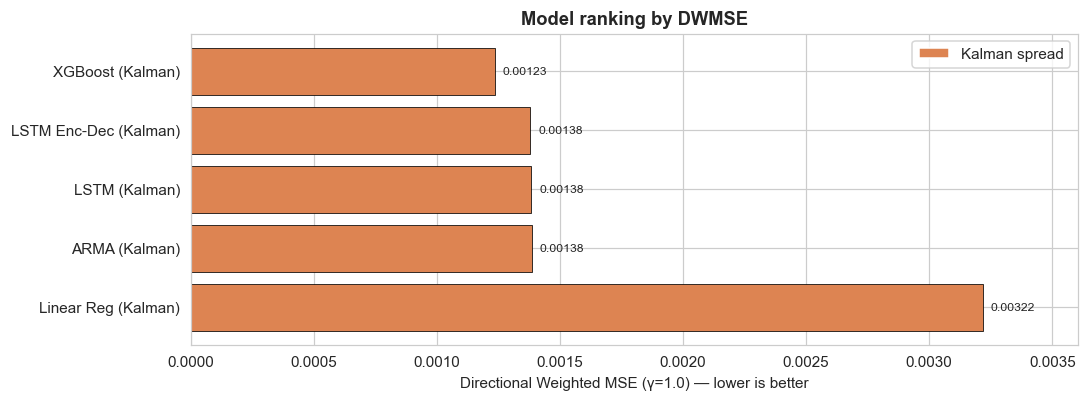

In [7]:
fig, ax = plt.subplots(figsize=(10, 0.45 * len(overall_df) + 1.5))
colors = ["#4C72B0" if s == "ols" else "#DD8452" for s in overall_df["spread_type"]]
bars = ax.barh(overall_df["model"], overall_df["dwmse"], color=colors,
               edgecolor="black", linewidth=0.5)
ax.invert_yaxis()  # best on top
ax.set_xlabel(f"Directional Weighted MSE (γ={GAMMA}) — lower is better")
ax.set_title("Model ranking by DWMSE")
# Value labels
pad = overall_df["dwmse"].max() * 0.01
for bar, val in zip(bars, overall_df["dwmse"]):
    ax.text(val + pad, bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va="center", fontsize=8)
ax.legend(handles=[Patch(facecolor="#DD8452", label="Kalman spread")],
          loc="upper right", frameon=True)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 7. Per-window DWMSE heatmap

Lets you spot models that win on average but blow up in individual folds — a model that is never the best but also never terrible is often preferable in practice.

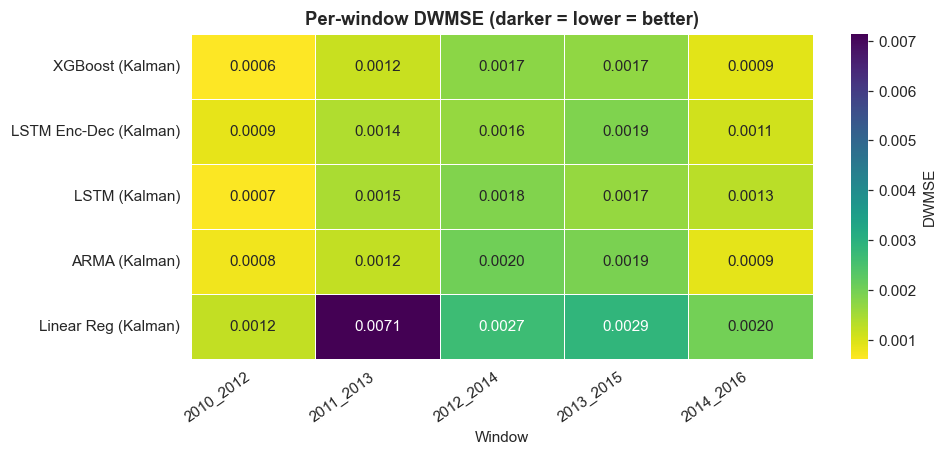

In [8]:
window_rows = []
for name, df in model_preds.items():
    for win, wdf in df.groupby("window"):
        a = wdf["actual_change"].to_numpy()
        p = wdf["predicted_change"].to_numpy()
        mask = np.isfinite(a) & np.isfinite(p)
        if mask.sum() == 0:
            continue
        window_rows.append({
            "model":  name,
            "window": win,
            "dwmse":  compute_dwmse(a[mask], p[mask]),
            "n_obs":  int(mask.sum()),
        })
window_df = pd.DataFrame(window_rows)

pivot = (window_df.pivot(index="model", columns="window", values="dwmse")
                  .reindex(overall_df["model"]))

fig, ax = plt.subplots(figsize=(min(14, 1.2 * pivot.shape[1] + 3),
                                0.45 * pivot.shape[0] + 2))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis_r",
            cbar_kws={"label": "DWMSE"}, ax=ax, linewidths=0.4, linecolor="white")
ax.set_title("Per-window DWMSE (darker = lower = better)")
ax.set_xlabel("Window")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 8. DWMSE vs plain MSE

The dashed line is $\text{DWMSE} = 0.5 \cdot \text{MSE}$, which a model with perfect directional accuracy would sit on. The vertical gap above that line is the directional penalty — models well above it are getting the sign wrong on their large errors.

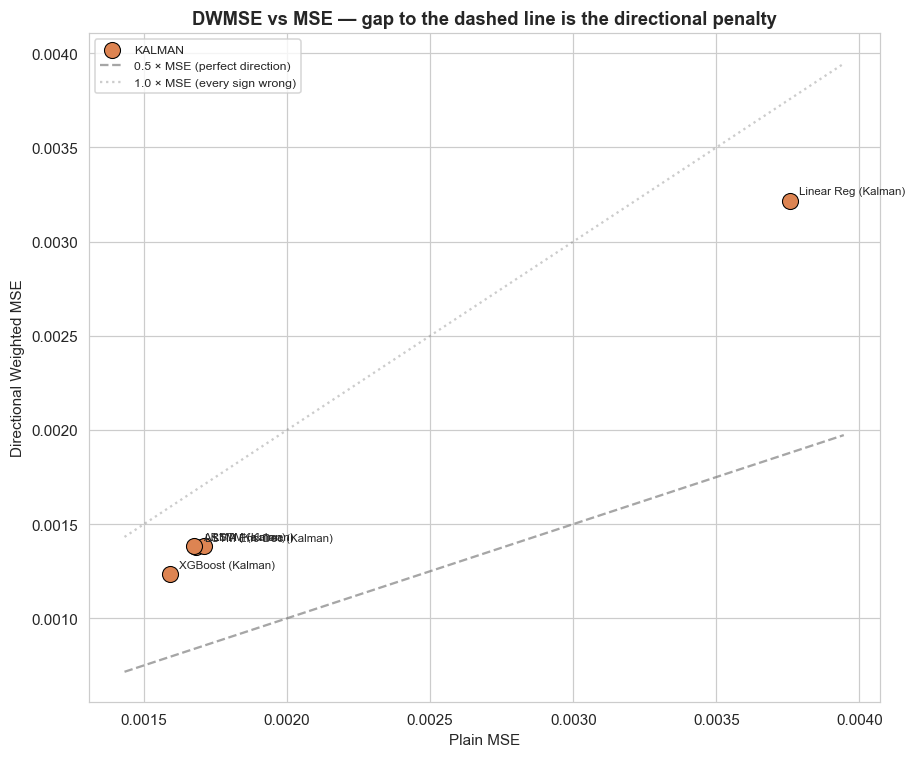

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 7))
for spread, color in [("kalman", "#DD8452")]:
    sub = overall_df[overall_df["spread_type"] == spread]
    ax.scatter(sub["mse"], sub["dwmse"], s=110, color=color,
               edgecolor="black", linewidth=0.7, label=spread.upper(), zorder=3)

# 0.5 × MSE reference (perfect directional accuracy)
lo = 0.9 * overall_df["mse"].min()
hi = 1.05 * overall_df["mse"].max()
xs = np.linspace(lo, hi, 50)
ax.plot(xs, 0.5 * xs,  "--", color="gray", alpha=0.7,
        label="0.5 × MSE (perfect direction)")
ax.plot(xs,        xs, ":",  color="gray", alpha=0.4,
        label="1.0 × MSE (every sign wrong)")

for _, r in overall_df.iterrows():
    ax.annotate(r["model"], (r["mse"], r["dwmse"]),
                fontsize=7.5, xytext=(6, 4), textcoords="offset points")

ax.set_xlabel("Plain MSE")
ax.set_ylabel("Directional Weighted MSE")
ax.set_title("DWMSE vs MSE — gap to the dashed line is the directional penalty")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Per-pair DWMSE distribution

Aggregates hide cross-pair variance. A model with the best pooled DWMSE might still be worse than a competitor on most individual pairs if a few pairs dominate the pooled average.

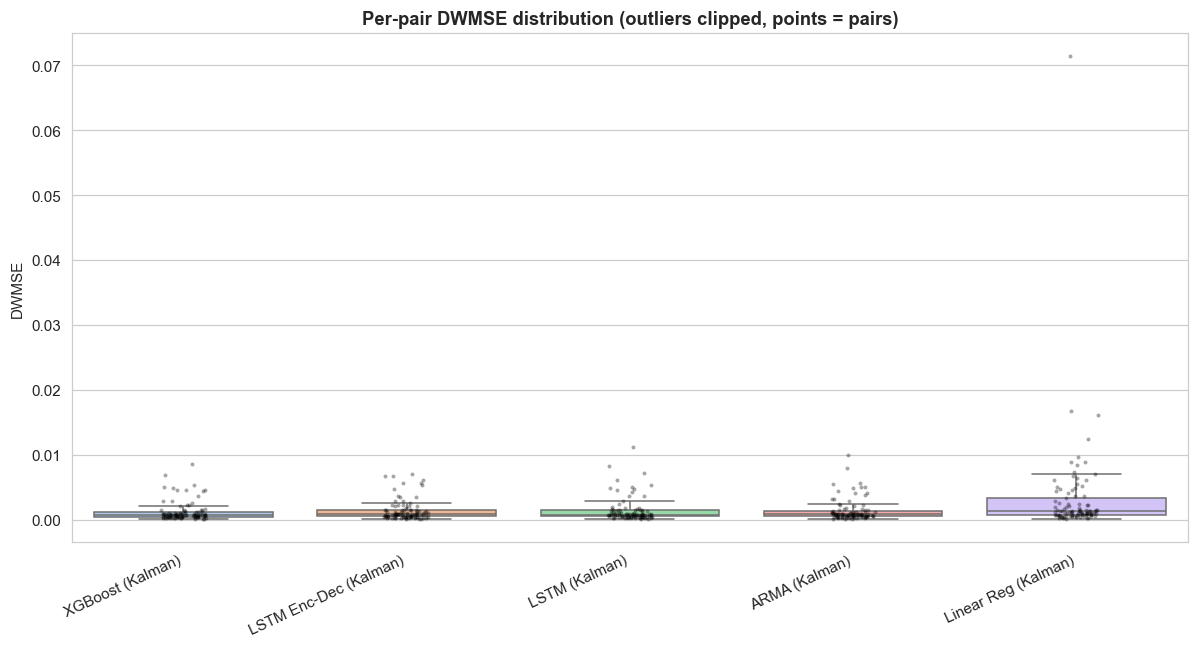

,count,mean,50%,std
model,,,,
ARMA (Kalman),97.0,0.001396,0.000808,0.001699
LSTM (Kalman),97.0,0.001406,0.000744,0.001853
LSTM Enc-Dec (Kalman),97.0,0.001398,0.000839,0.001580
Linear Reg (Kalman),97.0,0.003264,0.001262,0.007686
XGBoost (Kalman),97.0,0.001248,0.000738,0.001522


In [10]:
pair_rows = []
for name, df in model_preds.items():
    for pair, pdf in df.groupby("pair"):
        a = pdf["actual_change"].to_numpy()
        p = pdf["predicted_change"].to_numpy()
        mask = np.isfinite(a) & np.isfinite(p)
        if mask.sum() < 10:
            continue
        pair_rows.append({
            "model": name,
            "pair":  pair,
            "dwmse": compute_dwmse(a[mask], p[mask]),
            "n_obs": int(mask.sum()),
        })
pair_level = pd.DataFrame(pair_rows)

order = overall_df["model"].tolist()
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=pair_level, x="model", y="dwmse", order=order,
            ax=ax, showfliers=False, palette="pastel")
sns.stripplot(data=pair_level, x="model", y="dwmse", order=order,
              ax=ax, size=2.6, color="black", alpha=0.35)
ax.set_title("Per-pair DWMSE distribution (outliers clipped, points = pairs)")
ax.set_ylabel("DWMSE")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

pair_level.groupby("model")["dwmse"].describe()[["count", "mean", "50%", "std"]].round(6)

## 10. OU family

The OU models (baseline AR(1), OU+GARCH, regime-switching OU, VECM) write a single wide CSV (`ou_baseline_signals_extended.csv`) with one prediction column per variant, all built on the Kalman spread inside `ou_extended.py`. We align them against the Kalman labels from the pair datasets and score each variant the same way.

In [11]:
ou_overall = pd.DataFrame()

if OU_SIGNALS_PATH.exists():
    ou_raw = pd.read_csv(OU_SIGNALS_PATH, parse_dates=["date"]).rename(columns={"date": "Date"})
    ou_raw["pair"] = ou_raw["pair"].astype(str)

    # optional: keep only rows with prediction + actual
    required_cols = ["Date", "pair", "method", "actual_change_10d", "pred_change_10d"]
    missing = [c for c in required_cols if c not in ou_raw.columns]
    if missing:
        raise ValueError(f"OU signals file is missing required columns: {missing}")

    sub = ou_raw[required_cols].dropna(subset=["actual_change_10d", "pred_change_10d"]).copy()

    if sub.empty:
        print("No valid OU rows with both actual_change_10d and pred_change_10d.")
    else:
        m = evaluate_regression_predictions(
            sub["actual_change_10d"].to_numpy(),
            sub["pred_change_10d"].to_numpy(),
            gamma=GAMMA,
        )

        method_name = sub["method"].mode().iloc[0] if "method" in sub.columns and not sub["method"].empty else "unknown"
        pretty_name = f"OU ({method_name.capitalize()})"

        ou_overall = pd.DataFrame([{
            "model": pretty_name,
            "spread_type": method_name,
            "n_obs": int(len(sub)),
            "dwmse": m["directional_weighted_mse"],
            "mse": m["rmse"] ** 2,
            "rmse": m["rmse"],
            "dir_acc": m["directional_accuracy"],
            "r2": m["r2"],
            "ic": m["information_coefficient"],
        }]).sort_values("dwmse").reset_index(drop=True)
else:
    print(f"OU signals file not found: {OU_SIGNALS_PATH}")

ou_overall

,model,spread_type,n_obs,dwmse,mse,rmse,dir_acc,r2,ic
0,OU (Kalman),kalman,23125,0.0018,0.002043,0.0452,0.493146,-0.234266,-0.028615


## 11. Combined leaderboard — ML models + OU

In [12]:
combined = pd.concat(
    [
        overall_df.assign(family="ML (supervised)"),
        ou_overall.assign(family="OU family") if not ou_overall.empty else pd.DataFrame(),
    ],
    ignore_index=True,
).sort_values("dwmse").reset_index(drop=True)

combined["rank"] = combined["dwmse"].rank(method="min").astype("Int64")
combined = combined[["rank", "model", "spread_type", "family",
                     "n_obs", "dwmse", "mse", "dir_acc", "r2", "ic"]].set_index("rank")
combined

,model,spread_type,family,n_obs,dwmse,mse,dir_acc,r2,ic
rank,,,,,,,,,
1,XGBoost (Kalman),kalman,ML (supervised),23520,0.001235,0.001591,0.522789,-0.006005,0.033758
2,LSTM Enc-Dec (Kalman),kalman,ML (supervised),21520,0.001379,0.001681,0.518448,-0.094972,0.051344
3,LSTM (Kalman),kalman,ML (supervised),22320,0.001384,0.001708,0.538217,-0.085894,0.072973
4,ARMA (Kalman),kalman,ML (supervised),23520,0.001384,0.001675,0.547364,-0.058954,0.073061
5,OU (Kalman),kalman,OU family,23125,0.001800,0.002043,0.493146,-0.234266,-0.028615
6,Linear Reg (Kalman),kalman,ML (supervised),23520,0.003218,0.003757,0.492730,-1.375537,-0.014328


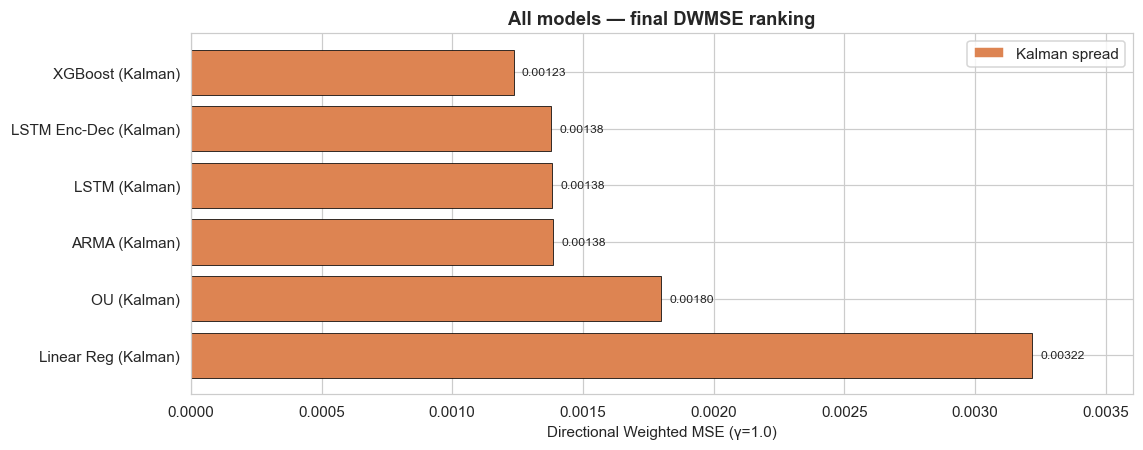

Best DWMSE: XGBoost (Kalman) (kalman) @ 0.001235 (dir_acc=0.523, R²=-0.0060, n=23,520)


In [13]:
if not ou_overall.empty:
    full = pd.concat([overall_df, ou_overall], ignore_index=True).sort_values("dwmse").reset_index(drop=True)
else:
    full = overall_df.copy()

fig, ax = plt.subplots(figsize=(10.5, 0.45 * len(full) + 1.5))
colors = ["#4C72B0" if s == "ols" else "#DD8452" for s in full["spread_type"]]
bars = ax.barh(full["model"], full["dwmse"], color=colors, edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"Directional Weighted MSE (γ={GAMMA})")
ax.set_title("All models — final DWMSE ranking")
pad = full["dwmse"].max() * 0.01
for bar, val in zip(bars, full["dwmse"]):
    ax.text(val + pad, bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va="center", fontsize=8)
ax.legend(handles=[Patch(facecolor="#DD8452", label="Kalman spread")],
          loc="upper right")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

best = full.iloc[0]
print(f"Best DWMSE: {best['model']} ({best['spread_type']}) @ {best['dwmse']:.6f} "
      f"(dir_acc={best['dir_acc']:.3f}, R²={best['r2']:.4f}, n={best['n_obs']:,})")

## 12. Directional accuracy comparison

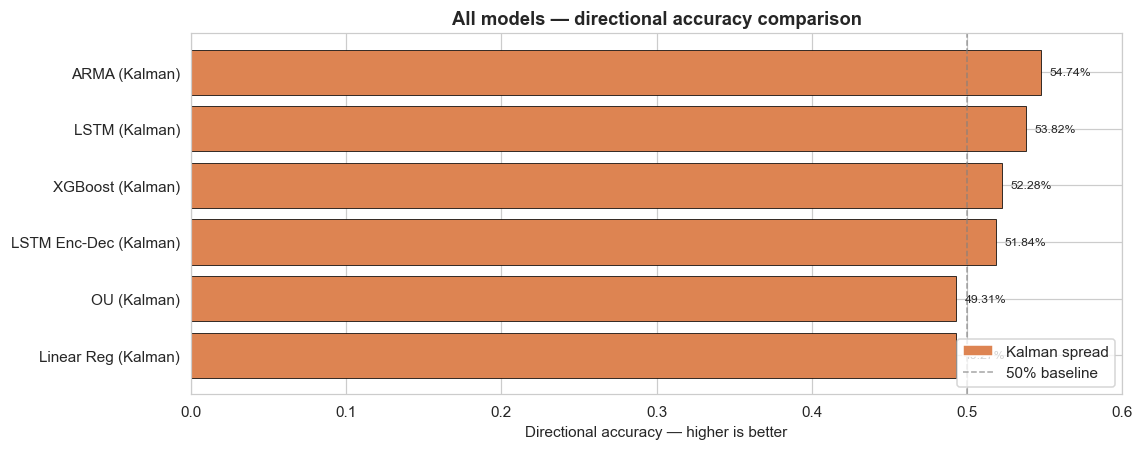

Best directional accuracy: ARMA (Kalman) (kalman) @ 54.74% (DWMSE=0.001384, n=23,520)


In [14]:
dir_full = full.sort_values("dir_acc", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 0.45 * len(dir_full) + 1.5))
colors = ["#4C72B0" if s == "ols" else "#DD8452" for s in dir_full["spread_type"]]
bars = ax.barh(dir_full["model"], dir_full["dir_acc"], color=colors,
               edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel("Directional accuracy — higher is better")
ax.set_title("All models — directional accuracy comparison")
ax.set_xlim(0, max(0.6, dir_full["dir_acc"].max() * 1.08))

pad = dir_full["dir_acc"].max() * 0.01 if len(dir_full) else 0.005
for bar, val in zip(bars, dir_full["dir_acc"]):
    ax.text(val + pad, bar.get_y() + bar.get_height()/2,
            f"{val:.2%}", va="center", fontsize=8)

ax.axvline(0.5, linestyle="--", color="gray", alpha=0.7, linewidth=1,
           label="50% (random sign baseline)")
ax.legend(handles=[
    Patch(facecolor="#DD8452", label="Kalman spread"),
    plt.Line2D([0], [0], linestyle="--", color="gray", alpha=0.7, linewidth=1,
               label="50% baseline"),
], loc="lower right")
ax.margins(x=0.02)
plt.tight_layout()
plt.show()

best_dir = dir_full.iloc[0]
print(f"Best directional accuracy: {best_dir['model']} ({best_dir['spread_type']}) @ "
      f"{best_dir['dir_acc']:.2%} (DWMSE={best_dir['dwmse']:.6f}, n={best_dir['n_obs']:,})")

## 13. Reading guide

- **γ = 1.0** — a wrong-sign prediction gets a 2× squared-error penalty compared to a right-sign one. The 0.5 prefactor means a model with *zero* sign errors scores DWMSE = ½·MSE, which is the lower dashed reference line in section 8.
- **Pooled sample differences** — not every model has predictions for the exact same (Date, pair) rows, because each model skips different rows during preprocessing (NaN handling, minimum-history filters, window-size cutoffs). The per-window heatmap is the fairer comparison.
- **OU vs ML** — OU results should be interpreted within the same spread type. Since `ou.py` outputs separate Kalman and static OU signal files, comparisons to other models should be made against models using the same target spread. Cross-spread comparisons are not directly comparable.
- **DWMSE vs directional accuracy** — directional accuracy is sample-average whereas DWMSE is error-weighted. A model can have mediocre directional accuracy yet good DWMSE if it gets the direction right on the *large* moves and only misses small ones.